# Demonstration und Evaluation: Modell-Logik und Ablationsstudie

**Autor:** Nikolai Steffan
**Bezug:** Kapitel 7.1 und 7.2 der Studienarbeit
**Ziel:** Dieses Notebook dient der technischen Validierung der gelernten Repräsentationen (Embedding-Analyse) sowie der Überprüfung von Architekturentscheidungen (Ablationsstudie zum [SEP]-Token).

---

## 1. Einleitung und Zielsetzung

Gemäß der Evaluationsphase des DSR-Frameworks (Phase 5) werden hier zwei zentrale Forschungsfragen experimentell untersucht:

1.  **Numerische Semantik (Kapitel 7.1):** Hat das Modell eine generische Zahlenlogik gelernt oder interpretiert es Werte kontextabhängig (z.B. ist `0.75` bei einem bestimmten Feature eine Anomalie)?
2.  **Strukturelle Relevanz (Kapitel 7.2):** Ist das explizite `[SEP]`-Token zur Trennung von Merkmalen notwendig, oder kann der Self-Attention-Mechanismus die Struktur implizit erfassen?

---

## 2. Setup: Importieren der Bibliotheken und Konfiguration

Initialisierung der Umgebung, Definition der Pfade zu den trainierten Modellen (Baseline und No-SEP Variante) und Konfiguration der Hardware-Beschleunigung.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import logging
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Logging Setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Device Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-21 07:56:13.323698: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU Memory: 23.6 GB


In [7]:
# Konfiguration - Passe diese Werte an deine Bedürfnisse an
CONFIG = {
    'MODEL_NAME': "huawei-noah/TinyBERT_General_4L_312D",  # TinyBERT Model
    'Train_DATA_CSV_PATH': "Project/bert_train_sequences_v4.csv",                   # Pfad zu deinen Trainingsdaten
    'Train_LABELS_CSV_PATH': "Project/y_train_resampled_attackCategoryEncoded.csv",               # Pfad zu deinen Labels
    'Eval_LABELS_CSV_PATH': "Project/y_test_Attack_Category_Encoded.csv",               # Pfad zu deinen Labels
    'Eval_DATA_CSV_PATH': "Project/bert_test_sequences_v4.csv",                   # Pfad zu deinen Trainingsdaten
    'LABEL_COLUMN_TRAIN': 'attackCategoryEncoded',
    'LABEL_COLUMN_TEST': 'Attack_Category_Encoded',            # Spalte mit den encodeten Labels
    'OUTPUT_DIR': "./tinybert_finetuned_v7",
}


print("Konfiguration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Konfiguration:
  MODEL_NAME: huawei-noah/TinyBERT_General_4L_312D
  Train_DATA_CSV_PATH: Project/bert_train_sequences_v4.csv
  Train_LABELS_CSV_PATH: Project/y_train_resampled_attackCategoryEncoded.csv
  Eval_LABELS_CSV_PATH: Project/y_test_Attack_Category_Encoded.csv
  Eval_DATA_CSV_PATH: Project/bert_test_sequences_v4.csv
  LABEL_COLUMN_TRAIN: attackCategoryEncoded
  LABEL_COLUMN_TEST: Attack_Category_Encoded
  OUTPUT_DIR: ./tinybert_finetuned_v7


---

## 3. Datenbasis

Laden des **NF-UNSW-NB15-v3** Testdatensatzes für die weiteren Experimente. 

In [ ]:
def load_and_prepare_data(data_csv_path, labels_csv_path, label_column):
    """
    Lädt und bereitet die Daten vor
    
    Args:
        data_csv_path: Pfad zur CSV mit den Trainingsdaten
        labels_csv_path: Pfad zur CSV mit den Labels
        label_column: Name der Spalte mit den encodeten Labels
    
    Returns:
        texts, labels: Vorbereitete Texte und Labels
    """
    logger.info("Lade Daten...")
    
    # Daten laden
    data_df = pd.read_csv(data_csv_path, sep='\t', encoding='utf-8')
    labels_df = pd.read_csv(labels_csv_path, sep='\t', encoding='utf-8')
    
    logger.info(f"Daten shape: {data_df.shape}")
    logger.info(f"Labels shape: {labels_df.shape}")
    logger.info(f"Labels shape: {labels_df.columns}")
    
    # Überprüfe ob die Anzahl der Zeilen übereinstimmt
    if len(data_df) != len(labels_df):
        raise ValueError(f"Anzahl der Datenzeilen ({len(data_df)}) stimmt nicht mit Anzahl der Labels ({len(labels_df)}) überein!")
    
    # Annahme: die erste Spalte in data_df enthält die formatierten Texte
    texts = data_df.iloc[:, 0].tolist()
    
    # Labels aus der spezifizierten Spalte laden (bereits encoded)
    if label_column not in labels_df.columns:
        raise ValueError(f"Label Spalte '{label_column}' nicht in den Label-Daten gefunden!")
    
    labels = labels_df[label_column].values
    
    logger.info(f"Anzahl unique Labels: {len(np.unique(labels))}")
    logger.info(f"Label Bereich: {np.min(labels)} - {np.max(labels)}")
    
    return texts, labels

# Daten laden
train_texts, train_labels = load_and_prepare_data(
    CONFIG['Train_DATA_CSV_PATH'], 
    CONFIG['Train_LABELS_CSV_PATH'], 
    CONFIG['LABEL_COLUMN_TRAIN']
)
val_texts, val_labels = load_and_prepare_data(
    CONFIG['Eval_DATA_CSV_PATH'], 
    CONFIG['Eval_LABELS_CSV_PATH'], 
    CONFIG['LABEL_COLUMN_TEST']
)
print(f"\nDaten erfolgreich geladen:")
print(f"Anzahl Samples: {len(train_texts)}")
print(f"Anzahl unique Labels: {len(np.unique(train_labels))}")

INFO:__main__:Lade Daten...
INFO:__main__:Daten shape: (2000000, 1)
INFO:__main__:Labels shape: (2000000, 1)
INFO:__main__:Labels shape: Index(['attackCategoryEncoded'], dtype='object')
INFO:__main__:Anzahl unique Labels: 10
INFO:__main__:Label Bereich: 0 - 9
INFO:__main__:Lade Daten...
INFO:__main__:Daten shape: (473085, 1)
INFO:__main__:Labels shape: (473085, 3)
INFO:__main__:Labels shape: Index(['Attack', 'Label', 'Attack_Category_Encoded'], dtype='object')
INFO:__main__:Anzahl unique Labels: 10
INFO:__main__:Label Bereich: 0 - 9



Daten erfolgreich geladen:
Anzahl Samples: 2000000
Anzahl unique Labels: 10


---
## 4. Analyse der Relevanz von Token Embeddings und der strukturellen Tokens im Modell

In diesem Abschnitt führen wir eine Reihe von tiefergehenden Experimenten durch, um besser zu verstehen, wie das Modell intern arbeitet. Diese Analysen sind nicht für die reine Leistungsevaluation notwendig, geben aber wertvolle Einblicke in die erlernten Repräsentationen.


### 4.1 Visualisierung von Token-Embeddings mittels PCA

Wie repräsentiert das Modell die Eingabe-Tokens intern? Um dies zu visualisieren, extrahieren wir die Vektor-Repräsentationen (Embeddings) aller Tokens aus dem letzten Layer des Transformers für einen Beispielsatz. Da diese Vektoren eine hohe Dimensionalität haben (z.B. 312 Dimensionen), reduzieren wir sie mit der **Principal Component Analysis (PCA)** auf zwei Dimensionen.

Im resultierenden Plot können wir die räumliche Anordnung der Tokens untersuchen. Tokens, die semantisch ähnlich sind, sollten tendenziell näher beieinander liegen.

Lade Modell und Tokenizer von: ./Project/tinybert_finetuned_v7
Modell und Tokenizer erfolgreich geladen.
\nAnalysiere folgenden Text:\n[CLS] dstToSrcAvgThroughput: 0.83 [SEP] dstToSrcIatAvg: 0.00 [SEP] dstToSrcSecondBytes: 0.48 [SEP] inBytes: 0.29 [SEP] inPkts: 0.07 [SEP] longestFlowPkt: 0.57 [SEP] minIpPktLen: 0.66 [SEP] numPkts128To256Bytes: 0.00 [SEP] outBytes: 0.31 [SEP] retransmittedInBytes: 0.00 [SEP] shortestFlowPkt: 0.52 [SEP] srcToDstSecondBytes: 0.61 [SEP] l7Proto: 103 [SEP] dnsQueryType: 1 [SEP] icmpIpv4Type: 0 [SEP]
\nForm der extrahierten Token-Embeddings: (160, 312)
(Anzahl Tokens, Embedding-Dimension)
\nFühre PCA zur Reduktion auf 2 Dimensionen durch...
Form nach PCA: (160, 2)
Erstelle Visualisierung...


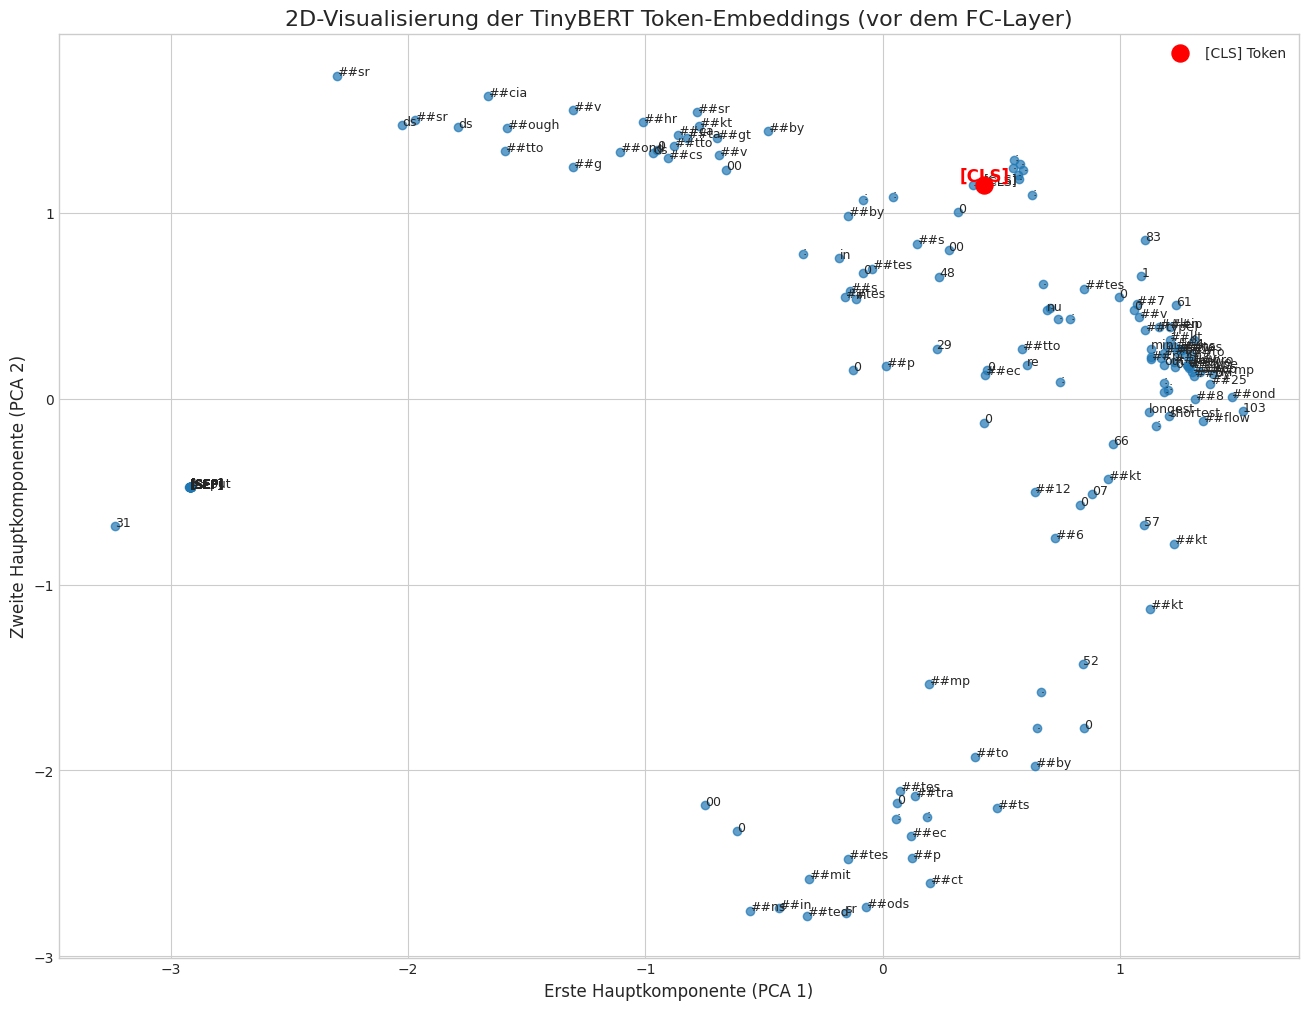

In [ ]:
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Konfiguration ---
# Stellen Sie sicher, dass dieser Pfad auf Ihr trainiertes Modell verweist
# In Ihrem Notebook war dies CONFIG['OUTPUT_DIR']
MODEL_PATH = "./Project/tinybert_finetuned_v7"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 2. Modell und Tokenizer laden ---
print(f"Lade Modell und Tokenizer von: {MODEL_PATH}")
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_PATH,
        output_hidden_states=True  # WICHTIG: Um auf die Hidden States zugreifen zu können
    )
    model.to(DEVICE)
    model.eval()
    print("Modell und Tokenizer erfolgreich geladen.")
except Exception as e:
    print(f"Fehler beim Laden des Modells: {e}")
    print("Stellen Sie sicher, dass der MODEL_PATH korrekt ist und das Modell dort gespeichert wurde.")

# --- 3. Beispielsatz auswählen ---
# Wir nehmen einen Beispielsatz aus Ihren Validierungsdaten.
# Sie können hier jeden beliebigen Text einfügen.
# Der Text ist bewusst komplex, um die Anordnung vieler Tokens zu sehen.
sample_text = val_texts[0] 
print(f"\\nAnalysiere folgenden Text:\\n{sample_text}")


# --- 4. Hidden States extrahieren ---
# Tokenisieren Sie den Text
inputs = tokenizer(sample_text, return_tensors="pt").to(DEVICE)

# Führen Sie die Inferenz durch
with torch.no_grad():
    outputs = model(**inputs)

# Extrahieren Sie den letzten Hidden State
# outputs.hidden_states ist ein Tupel mit allen Hidden States (inkl. Embedding Layer)
# Der letzte Eintrag (-1) ist der Output des letzten Transformer-Layers
last_hidden_state = outputs.hidden_states[-1]

# Entfernen Sie die Batch-Dimension und konvertieren Sie zu NumPy
token_embeddings = last_hidden_state.squeeze(0).cpu().numpy()

# Holen Sie die Tokens als Strings für die Beschriftung des Plots
input_ids = inputs['input_ids'].squeeze(0).cpu().numpy()
tokens = tokenizer.convert_ids_to_tokens(input_ids)

print(f"\\nForm der extrahierten Token-Embeddings: {token_embeddings.shape}")
print(f"(Anzahl Tokens, Embedding-Dimension)")


# --- 5. PCA zur Dimensionsreduktion ---
print("\\nFühre PCA zur Reduktion auf 2 Dimensionen durch...")
pca = PCA(n_components=2)
token_embeddings_2d = pca.fit_transform(token_embeddings)

print(f"Form nach PCA: {token_embeddings_2d.shape}")


# --- 6. Visualisierung ---
print("Erstelle Visualisierung...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(16, 12))

# Scatter-Plot der Token-Positionen
ax.scatter(token_embeddings_2d[:, 0], token_embeddings_2d[:, 1], alpha=0.7)

# Jeden Punkt mit dem zugehörigen Token beschriften
for i, token in enumerate(tokens):
    # Ignoriere Padding-Tokens für eine bessere Lesbarkeit
    if token != '[PAD]':
        ax.annotate(token, (token_embeddings_2d[i, 0], token_embeddings_2d[i, 1]), fontsize=9)

# Hebe den [CLS] Token hervor
try:
    cls_index = tokens.index('[CLS]')
    ax.scatter(token_embeddings_2d[cls_index, 0], token_embeddings_2d[cls_index, 1], 
               color='red', s=150, label='[CLS] Token', zorder=5)
    ax.annotate('[CLS]', (token_embeddings_2d[cls_index, 0], token_embeddings_2d[cls_index, 1]), 
                color='red', weight='bold', fontsize=12, ha='center', va='bottom')
except ValueError:
    print("Hinweis: [CLS] Token nicht im Sample gefunden.")


plt.title('2D-Visualisierung der TinyBERT Token-Embeddings (vor dem FC-Layer)', fontsize=16)
plt.xlabel('Erste Hauptkomponente (PCA 1)', fontsize=12)
plt.ylabel('Zweite Hauptkomponente (PCA 2)', fontsize=12)
plt.legend()
plt.show()

**Beobachtung**: Der Plot offenbart ein signifikantes Muster im Verhalten von Trennzeichen:

- **[SEP]-Tokens (Cluster)**: Alle [SEP]-Tokens liegen extrem dicht beieinander und bilden quasi einen einzigen Punkt. Sie weisen eine Varianz von nahe Null auf.

- **Doppelpunkte (Streuung)**: Im Kontrast dazu sind die Doppelpunkte (:), die Features und Werte trennen, weit über den Vektorraum verstreut.

**Interpretation**: Dieser visuelle Befund liefert eine tiefe Einsicht in die Funktionsweise des fine-getunten Modells:

- **Strukturelle Konstante**: Das Modell hat gelernt, dass das [SEP]-Token eine rein technische, statische Funktion ("Sequenzende") hat. Es trägt keinerlei kontextuelle Information. Dies ist eine starke qualitative Bestätigung für die Ergebnisse der Ablationsstudie in Kapitel 7.2: Da das Token keine Information enthält, führt sein Entfernen auch zu keinem Leistungsabfall.

- **Kontextuelle Bindung**: Der Doppelpunkt hingegen agiert als semantischer "Klebstoff". Durch den Self-Attention-Mechanismus absorbiert er den Kontext der umliegenden Wörter (z.B. bedeutet ein : nach "IP" etwas anderes als nach "Duration"). Seine Position im Raum ist daher hochgradig kontextabhängig.



### 4.2. Ablationsstudie zum [SEP]-Token

In **Kapitel 7.2** wird aufgrund der vorhergehenden Analyse die Hypothese aufgestellt, dass das `[SEP]`-Token für die Klassifikationsleistung redundant ist, da der Self-Attention-Mechanismus strukturelle Grenzen implizit lernt.

Um dies zu quantifizieren, vergleichen wir die Performance-Metriken (Accuracy, Precision, Recall, F1-Score) des **Baseline-Modells** mit denen des **No-SEP-Modells**.

Hierfür wird in der folgenden Zelle ein Datensatz ohne SEP Tokens erstellt.


In [82]:
import pandas as pd

# --- 1. Konfiguration: Dateipfade ---

# Pfade zu den Originaldateien (aus Ihrer Konfiguration)
original_train_file = './Project/bert_train_sequences_v4.csv'
original_test_file = './Project/bert_test_sequences_v4.csv'

# Namen für die neuen, modifizierten Dateien
new_train_file = './Project/bert_train_sequences_v4_no_sep.csv'
new_test_file = './Project/bert_test_sequences_v4_no_sep.csv'

print("--- Starte Modifikation der Datensätze ---")

# --- 2. Funktion zur Verarbeitung einer Datei ---

def remove_sep_from_file(input_path, output_path):
    """
    Liest eine CSV-Datei, entfernt ' [SEP] ' aus der ersten Spalte 
    und speichert das Ergebnis in einer neuen CSV-Datei.
    """
    try:
        # Lade die Daten. Annahme: Tab-separiert, erste Spalte enthält die Sequenz.
        print(f"Lese Originaldatei: {input_path} ...")
        df = pd.read_csv(input_path, sep='\t', header=None, encoding='utf-8')
        
        # Die Sequenzen sind in der ersten Spalte (Index 0)
        sequences_col = df.iloc[:, 0]
        
        # Ersetze ' [SEP] ' durch ein einzelnes Leerzeichen
        # Die Leerzeichen um [SEP] sind wichtig, um saubere Abstände zu erhalten
        print("Entferne '[SEP]'-Tokens...")
        modified_sequences = sequences_col.str.replace(' [SEP] ', ' ', regex=False)
        
        # Erstelle einen neuen DataFrame mit den modifizierten Daten
        new_df = pd.DataFrame(modified_sequences)
        print(new_df.head())
        # Speichere die modifizierten Daten
        print(f"Speichere modifizierte Datei: {output_path} ...")
        new_df.to_csv(output_path, sep='\t', header=False, index=False, encoding='utf-8')
        
        print(f"Erfolgreich abgeschlossen für {input_path}.\\n")
        return True
        
    except FileNotFoundError:
        print(f"FEHLER: Die Datei '{input_path}' wurde nicht gefunden. Bitte überprüfen Sie den Pfad.")
        return False
    except Exception as e:
        print(f"Ein unerwarteter Fehler ist aufgetreten bei {input_path}: {e}")
        return False

# --- 3. Verarbeitung für Trainings- und Testdaten durchführen ---

# Verarbeite die Trainingsdaten
success_train = remove_sep_from_file(original_train_file, new_train_file)

# Verarbeite die Testdaten
success_test = remove_sep_from_file(original_test_file, new_test_file)

# --- 4. Abschlussmeldung ---
if success_train and success_test:
    print("--- Alle Datensätze wurden erfolgreich modifiziert und gespeichert! ---")
    print(f"Neue Trainingsdaten: {new_train_file}")
    print(f"Neue Testdaten: {new_test_file}")
else:
    print("--- Die Verarbeitung wurde aufgrund von Fehlern abgebrochen. ---")

--- Starte Modifikation der Datensätze ---
Lese Originaldatei: ./Project/bert_train_sequences_v4.csv ...
Entferne '[SEP]'-Tokens...
                                                   0
0                                      bert_sequence
1  [CLS] dstToSrcAvgThroughput: 0.49 dstToSrcIatA...
2  [CLS] dstToSrcAvgThroughput: 0.55 dstToSrcIatA...
3  [CLS] dstToSrcAvgThroughput: 0.54 dstToSrcIatA...
4  [CLS] dstToSrcAvgThroughput: 0.56 dstToSrcIatA...
Speichere modifizierte Datei: ./Project/bert_train_sequences_v4_no_sep.csv ...
Erfolgreich abgeschlossen für ./Project/bert_train_sequences_v4.csv.\n
Lese Originaldatei: ./Project/bert_test_sequences_v4.csv ...
Entferne '[SEP]'-Tokens...
                                                   0
0                                      bert_sequence
1  [CLS] dstToSrcAvgThroughput: 0.83 dstToSrcIatA...
2  [CLS] dstToSrcAvgThroughput: 0.82 dstToSrcIatA...
3  [CLS] dstToSrcAvgThroughput: 0.75 dstToSrcIatA...
4  [CLS] dstToSrcAvgThroughput: 0.58 dstToSrcIa

Der Vergleich des SEP Modells und non SEP Modells wurde anhand der Classification Reports,die dies nach dem Training genierierten aufgestellt. Der Vergleich bestätigte die Annahme, dass der SEP Token nicht zur Modellperformance beiträgt. 

### 4.3. Technische Validierung des [CLS]-Token-Flaschenhalses

Bevor wir die Interpretierbarkeit der Modelle vergleichen, führen wir ein technisches Experiment durch, um die interne Funktionsweise der Standard-Klassifikation zu beweisen.

**Hypothese:**
Standard-BERT-Modelle nutzen für die Klassifikation ausschließlich den Vektor des ersten Tokens (`[CLS]`) und verwerfen die räumlichen Informationen aller anderen 191 Tokens im `BertPooler`-Layer. Dies erzeugt einen Informations-Flaschenhals, der die Interpretierbarkeit (z.B. durch SHAP) erschweren könnte.

**Experimenteller Aufbau:**
Um dies zu verifizieren, replizieren wir die Logik des `BertPooler` manuell und vergleichen das Ergebnis mit der automatischen Forward-Pass-Funktion:
1.  **Weg A (Manuell):** Wir extrahieren nur den Vektor an Index 0 (`[CLS]`) aus dem Hidden-State und leiten ihn manuell durch die dichte Schicht und die Tanh-Aktivierung.
2.  **Weg B (Automatisch):** Wir übergeben den gesamten Hidden-State (alle Tokens) an den Pooler.

Wenn `Weg A == Weg B`, ist bewiesen, dass das Modell alle anderen Tokens in diesem Schritt ignoriert. Dies liefert die theoretische Rechtfertigung für den Einsatz von **Global Average Pooling (GAP)** in der optimierten Variante.

In [78]:
import torch

# Annahmen: 'model', 'tokenizer', 'sample_text' und 'DEVICE' 
# sind aus den vorherigen Zellen noch verfügbar.

print("--- Beweis-Experiment: Wie arbeitet der BertPooler? ---")

# 1. Encoder-Output für einen Beispielsatz holen
inputs = tokenizer(sample_text, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    # Wir holen uns den Output des Basis-Modells (ohne den finalen Classifier)
    encoder_outputs = model.bert(**inputs)
    last_hidden_state = encoder_outputs.last_hidden_state
    # Die Form ist: [batch_size, anzahl_tokens, embedding_dimension]
    # z.B.: [1, 192, 312]

print(f"Form des kompletten Encoder-Outputs: {last_hidden_state.shape}")

# 2. Weg A: Manuelle Replikation der Pooler-Logik
# ------------------------------------------------
# Wir nehmen an, der Pooler nimmt nur den Vektor des ERSTEN Tokens ([CLS])
cls_token_embedding = last_hidden_state[:, 0]  # Index 0 für das erste Token
print(f"Form des manuell extrahierten [CLS]-Token-Vektors: {cls_token_embedding.shape}")

# Wir schicken diesen einen Vektor durch die internen Layer des Poolers
manual_result = model.bert.pooler.activation(
    model.bert.pooler.dense(cls_token_embedding)
)
print(f"Form des manuellen Ergebnisses: {manual_result.shape}")


# 3. Weg B: Automatische Ausführung des Poolers
# ---------------------------------------------
# Wir geben dem Pooler den kompletten Output des Encoders
automatic_result = model.bert.pooler(last_hidden_state)
print(f"Form des automatischen Ergebnisses: {automatic_result.shape}")


# 4. Der Vergleich: Sind die Ergebnisse identisch?
# -------------------------------------------------
# torch.allclose vergleicht zwei Tensoren auf (nahezu) exakte Gleichheit
is_identical = torch.allclose(manual_result, automatic_result)

print("\\n--- ERGEBNIS DES VERGLEICHS ---")
if is_identical:
    print("✅ Die Ergebnisse sind identisch!")
    print("\\nBeweis erbracht: Der BertPooler-Layer nimmt tatsächlich nur den Vektor des ersten Tokens ([CLS]) und verarbeitet diesen.")
else:
    print("❌ Die Ergebnisse sind nicht identisch. Das Experiment ist fehlgeschlagen.")


--- Beweis-Experiment: Wie arbeitet der BertPooler? ---
Form des kompletten Encoder-Outputs: torch.Size([1, 160, 312])
Form des manuell extrahierten [CLS]-Token-Vektors: torch.Size([1, 312])
Form des manuellen Ergebnisses: torch.Size([1, 312])
Form des automatischen Ergebnisses: torch.Size([1, 312])
\n--- ERGEBNIS DES VERGLEICHS ---
✅ Die Ergebnisse sind identisch!
\nBeweis erbracht: Der BertPooler-Layer nimmt tatsächlich nur den Vektor des ersten Tokens ([CLS]) und verarbeitet diesen.


## 5. Analyse der numerischen Logik (Embedding-Raum)

### 5.1. Methodik
Wie in **Kapitel 7.1** beschrieben, untersuchen wir die semantische Repräsentation numerischer Werte. Ein grundlegendes Problem bei der Anwendung von Transformer-Modellen auf tabellarische oder numerische Daten ist das "Verständnis" von Zahlen. Im Gegensatz zu Rechenwerken verarbeiten LLMs Zahlen als Text-Tokens (z. B. "-1.0", "0.0"). Für unser auf Netzwerksicherheit trainiertes Modell, dessen numerische Eingabedaten auf einen Bereich von 0 (Minimum) bis +1.0 (Maximum) standardisiert wurden, stellt sich somit folgende Frage: *Lernt das Modell eine lineare Skala (0.0 < 0.5 < 1.0) oder eine merkmalsabhängige Semantik?*

Wir formulierten drei konkurrierende Hypothesen:
- H1 (Sentiment-Achse): Das Modell behält eine generische, aus dem Pre-Training stammende Logik bei, bei der negative Zahlen mit negativ konnotierten Wörtern ("schlecht", "niedrig") und positive Zahlen mit positiv konnotierten Wörtern ("gut", "hoch") assoziiert werden.
- H2 (Generische Anomalie-Achse): Das Modell hat eine aufgabenspezifische Logik gelernt, bei der der Median (0.0) "Normalität" repräsentiert, während beide Extreme (0 und +1.0) semantisch als "Anomalie" oder "Abweichung" gruppiert werden.
- H3 (Merkmals-spezifische Anomalie-Achse): Die Logik aus H2 ist nicht generisch, sondern kontextabhängig. Das Modell wendet je nach vorangestelltem Feature-Namen (z. B. dstToSrcIatAvg:) eine unterschiedliche numerische Semantik an.

In [ ]:
import torch
import numpy as np
from transformers import AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import sys 

# === HELFERFUNKTIONEN (unverändert) ===

def get_embedding_vector(text: str, model, tokenizer) -> np.ndarray:
    """
    Kodiert Text, holt die Embeddings und mittelt sie über alle Tokens.
    Ignoriert [CLS] und [SEP] Tokens für die Mittelwertbildung.
    """
    # Tokenisieren ohne spezielle Tokens (CLS/SEP)
    inputs = tokenizer(text, return_tensors="pt", add_special_tokens=False)
    input_ids = inputs["input_ids"]

    # Verhindern, dass leere Eingaben (z.B. nach Tokenizer-Bereinigung) crashen
    if input_ids.shape[1] == 0:
        print(f"Warnung: Text '{text}' ergab keine validen Tokens. Überspringe.")
        # Rückgabe eines Null-Vektors in der richtigen Dimension
        return np.zeros(model.config.hidden_size)

    # Embeddings aus dem Modell holen (letzte verborgene Schicht)
    with torch.no_grad():
        outputs = model(**inputs)
        embeddings = outputs.last_hidden_state 
    
    # Mitteln der Token-Embeddings (dim=1 ist die Token-Dimension)
    avg_embedding = torch.mean(embeddings, dim=1).squeeze()
    
    return avg_embedding.cpu().numpy()

def calculate_set_similarity(set_a: list, set_b: list, model, tokenizer) -> float:
    """
    Berechnet die durchschnittliche Kosinusähnlichkeit zwischen zwei Sets von Texten.
    """
    vectors_a = [get_embedding_vector(text, model, tokenizer) for text in set_a]
    vectors_b = [get_embedding_vector(text, model, tokenizer) for text in set_b]
    
    vectors_a = np.array(vectors_a)
    vectors_b = np.array(vectors_b)
    
    # Sicherstellen, dass keine Null-Vektoren die Berechnung stören
    if vectors_a.shape[0] == 0 or vectors_b.shape[0] == 0 or \
       vectors_a.ndim == 1 or vectors_b.ndim == 1:
        print("Warnung: Eines der Sets ist leer oder enthält ungültige Vektoren. Gebe 0.0 zurück.")
        return 0.0
        
    # Kosinusähnlichkeit berechnen (ergibt eine Matrix)
    sim_matrix = cosine_similarity(vectors_a, vectors_b)
    
    return np.mean(sim_matrix)

# === HAUPTFUNKTION FÜR ALLE HYPOTHESEN ===

# === HAUPTFUNKTION FÜR ANGEPASSTE HYPOTHESEN ===

def test_embedding_hypotheses(model_path: str):
    """
    Führt den Embedding-Test für die an die [0, 1] Skalierung angepassten Hypothesen durch.
    """
    print(f"--- Starte angepasste Embedding-Analyse für: {model_path} ---")
    
    try:
        print("Lade Modell und Tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(model_path)
        model = AutoModel.from_pretrained(model_path)
        model.eval()
        print("Modell geladen.\n")
    except Exception as e:
        print(f"FEHLER: Modell konnte nicht geladen werden. Pfad: {model_path}")
        print(f"Details: {e}")
        return

    # ---
    # H1: SKALEN-ACHSE (Niedrig vs. Hoch)
    # ---
    print("=====================================================")
    print("  H1: Skalen-Achse (Niedrig vs. Hoch)")
    print("=====================================================")
    
    set_low_numbers = ["0", "0.0", "0.1"]
    set_high_numbers = ["1", "1.0", "0.9"]
    set_low_words = ["niedrig", "wenig", "gering", "minimum", "kein"]
    set_high_words = ["hoch", "viel", "maximal", "maximum", "voll"]
    
    sim_low_low = calculate_set_similarity(set_low_numbers, set_low_words, model, tokenizer)
    sim_high_high = calculate_set_similarity(set_high_numbers, set_high_words, model, tokenizer)
    sim_low_high = calculate_set_similarity(set_low_numbers, set_high_words, model, tokenizer)
    sim_high_low = calculate_set_similarity(set_high_numbers, set_low_words, model, tokenizer)

    print("\n--- Ergebnisse Hypothese 1 (Skala) ---")
    print(f"  Ähnlichkeit(Zahlen um 0, 'niedrig'-Wörter): {sim_low_low:.4f}  <-- ERW: HOCH")
    print(f"  Ähnlichkeit(Zahlen um 1, 'hoch'-Wörter):   {sim_high_high:.4f}  <-- ERW: HOCH")
    print(f"  Ähnlichkeit(Zahlen um 0, 'hoch'-Wörter):   {sim_low_high:.4f}  <-- ERW: NIEDRIG")
    print(f"  Ähnlichkeit(Zahlen um 1, 'niedrig'-Wörter): {sim_high_low:.4f}  <-- ERW: NIEDRIG")
    print("------------------------------------------\n")

    # ---
    # H2: GENERISCHE ANOMALIE-ACHSE
    # ---
    set_normal_words = ["normal", "median", "üblich", "durchschnittlich", "erwartet"]
    set_anomaly_words = ["anomalie", "abweichung", "extrem", "ungewöhnlich", "alarm", "kritisch"]
    
    # H2a: Mittelpunkt als Norm
    print("=====================================================")
    print("  H2a: Anomalie-Achse (Mittelpunkt als Norm)")
    print("=====================================================")
    set_median_numbers = ["0.5", "0.4", "0.6"]
    set_extreme_numbers = ["0", "1", "0.0", "1.0", "0.99"]
    
    sim_median_normal = calculate_set_similarity(set_median_numbers, set_normal_words, model, tokenizer)
    sim_extremes_anomaly = calculate_set_similarity(set_extreme_numbers, set_anomaly_words, model, tokenizer)
    sim_median_anomaly = calculate_set_similarity(set_median_numbers, set_anomaly_words, model, tokenizer)
    
    vec_0 = get_embedding_vector("0.0", model, tokenizer)
    vec_1 = get_embedding_vector("1.0", model, tokenizer)
    vec_05 = get_embedding_vector("0.5", model, tokenizer)
    sim_0_1 = cosine_similarity([vec_0], [vec_1])[0, 0]
    sim_0_05 = cosine_similarity([vec_0], [vec_05])[0, 0]
    
    print("\n--- Ergebnisse Hypothese 2a (Mittelpunkt als Norm) ---")
    print(f"  Ähnlichkeit(Zahlen um 0.5, 'normal'-Wörter): {sim_median_normal:.4f}  <-- ERW: HOCH")
    print(f"  Ähnlichkeit(Extreme 0 & 1, 'anomalie'-Wörter): {sim_extremes_anomaly:.4f}  <-- ERW: HOCH")
    print(f"  Ähnlichkeit(Zahlen um 0.5, 'anomalie'-Wörter): {sim_median_anomaly:.4f}  <-- ERW: NIEDRIG")
    print(f"  Ähnlichkeit('0.0' vs. '1.0'): {sim_0_1:.4f}  <-- ERW: HOCH (beides Extreme)")
    print(f"  Ähnlichkeit('0.0' vs. '0.5'): {sim_0_05:.4f}  <-- ERW: NIEDRIGER als '0.0' vs '1.0'")
    print("----------------------------------------------------\n")

    # H2b: Null als Norm
    print("=====================================================")
    print("  H2b: Anomalie-Achse (Null als Norm)")
    print("=====================================================")
    set_zero_numbers = ["0", "0.0"]
    set_high_val_numbers = ["1.0", "0.9", "1"]
    set_zero_normal_words = ["nichts", "keine aktivität", "ruhezustand", "unverändert", "normal"]

    sim_zero_normal = calculate_set_similarity(set_zero_numbers, set_zero_normal_words, model, tokenizer)
    sim_high_anomaly = calculate_set_similarity(set_high_val_numbers, set_anomaly_words, model, tokenizer)

    print("\n--- Ergebnisse Hypothese 2b (Null als Norm) ---")
    print(f"  Ähnlichkeit(Zahlen um 0, 'normal/nichts'-Wörter): {sim_zero_normal:.4f}  <-- ERW: HOCH")
    print(f"  Ähnlichkeit(Zahlen um 1, 'anomalie'-Wörter):      {sim_high_anomaly:.4f}  <-- ERW: HOCH")
    print("-------------------------------------------------\n")

    # ---
    # H3: MERKMALS-SPEZIFISCHE ACHSE
    # ---
    print("=====================================================")
    print("  H3: Merkmals-spezifische Matrix")
    print("=====================================================")
    feature_context = "dstToSrcAvgTroughput"
    print(f"  Testet die Ähnlichkeit für '{feature_context}' mit Werten von 0 bis 1.\n")
    
    numeric_points = ["0.0", "0.25", "0.5", "0.75", "1.0"]
    context_points = [f"{feature_context}: {p}" for p in numeric_points]
    context_vectors = {p: get_embedding_vector(p, model, tokenizer) for p in context_points}
    
    header = " " * 7 + "".join([f"{p:>7}" for p in numeric_points]) + "  "
    print(f"  Kosinus-Ähnlichkeitsmatrix (für '{feature_context}'):")
    print(f"  {header}")
    print("  " + "-" * (len(header) - 2))
    
    for i, p1_ctx in enumerate(context_points):
        row_str = f"   {numeric_points[i]:>4} |"
        for p2_ctx in context_points:
            sim = cosine_similarity([context_vectors[p1_ctx]], [context_vectors[p2_ctx]])[0, 0]
            row_str += f" ({sim:.3f})" if p1_ctx == p2_ctx else f"  {sim:.3f} "
        print(row_str + " ")
        
    print("\n  ERWARTUNG (z.B. für H2a - Mittelpunkt als Norm):")
    print("  - Symmetrische Matrix um 0.5.")
    print("  - Hoher Wert für (0.0 vs. 1.0).")
    print("  - Niedrigere Werte zwischen Extremen und Mitte (z.B. 0.0 vs 0.5).")
    print("----------------------------------------------------\n")



# === BEISPIEL-AUFRUF ===
if __name__ == "__main__":
    # HIER DEN PFAD ZU DEINEM MODELL EINFÜGEN
    MODEL_PFAD = "Project/tinybert_finetuned_v4" 
    
    test_embedding_hypotheses(MODEL_PFAD)

--- Starte angepasste Embedding-Analyse für: Project/tinybert_finetuned_v4 ---
Lade Modell und Tokenizer...
Modell geladen.

  H1: Skalen-Achse (Niedrig vs. Hoch)

--- Ergebnisse Hypothese 1 (Skala) ---
  Ähnlichkeit(Zahlen um 0, 'niedrig'-Wörter): 0.5404  <-- ERW: HOCH
  Ähnlichkeit(Zahlen um 1, 'hoch'-Wörter):   0.7040  <-- ERW: HOCH
  Ähnlichkeit(Zahlen um 0, 'hoch'-Wörter):   0.5600  <-- ERW: NIEDRIG
  Ähnlichkeit(Zahlen um 1, 'niedrig'-Wörter): 0.6423  <-- ERW: NIEDRIG
------------------------------------------

  H2a: Anomalie-Achse (Mittelpunkt als Norm)

--- Ergebnisse Hypothese 2a (Mittelpunkt als Norm) ---
  Ähnlichkeit(Zahlen um 0.5, 'normal'-Wörter): 0.5429  <-- ERW: HOCH
  Ähnlichkeit(Extreme 0 & 1, 'anomalie'-Wörter): 0.4568  <-- ERW: HOCH
  Ähnlichkeit(Zahlen um 0.5, 'anomalie'-Wörter): 0.5058  <-- ERW: NIEDRIG
  Ähnlichkeit('0.0' vs. '1.0'): 0.7668  <-- ERW: HOCH (beides Extreme)
  Ähnlichkeit('0.0' vs. '0.5'): 0.7528  <-- ERW: NIEDRIGER als '0.0' vs '1.0'
-------------

## 3. Modell-Erklärbarkeit mit SHAP (SHapley Additive exPlanations)

Eine der wichtigsten Fragen bei der Arbeit mit komplexen Modellen wie BERT ist: *Warum* hat das Modell eine bestimmte Entscheidung getroffen? SHAP ist eine leistungsstarke Methode aus der Spieltheorie, um genau das zu beantworten.

- **Ziel:** Wir wollen für eine gegebene Vorhersage (z.B. "Attack") herausfinden, welche Teile des Eingabetextes (also welche Merkmale und ihre Werte) die Entscheidung des Modells am stärksten in diese Richtung beeinflusst haben.
- **Vorgehen:**
    1. Wir erstellen einen `Explainer`, der unser Modell und den Tokenizer verwendet. Eine `prediction_wrapper`-Funktion ist notwendig, um die Ein- und Ausgaben für SHAP korrekt zu formatieren.
    2. Der `Explainer` generiert für jedes Token im Text einen "SHAP-Wert".
    3. Wir visualisieren diese Werte mit `shap.plots.text()`:
        - **Rote Token:** Tragen dazu bei, die Wahrscheinlichkeit der vorhergesagten Klasse zu **erhöhen**. Dies sind die "treibenden Kräfte" für die Entscheidung.
        - **Blaue Token:** Tragen dazu bei, die Wahrscheinlichkeit der vorhergesagten Klasse zu **senken**.

Dies ermöglicht eine intuitive, merkmalsbasierte Interpretation von Black-Box-Modellen.


In [ ]:
import shap
import torch
import numpy as np

# 1. Create the prediction wrapper function (with a fix)
def prediction_wrapper(texts):
    """
    Wrapper function to handle tokenization and model prediction
    for SHAP, ensuring inputs have a batch dimension.
    This version handles the numpy array passed by SHAP's explainer.
    """
    # SHAP's PartitionExplainer can pass numpy arrays, so we convert to list
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    # Tokenize the input texts
    # padding=True and truncation=True handle variable length sequences
    # return_tensors="pt" returns PyTorch tensors
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

    # Move tensors to the same device as the model
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Get model predictions without calculating gradients
    with torch.no_grad():
        outputs = model(**inputs)

    # We need the probabilities, so we apply softmax to the logits
    # and move the result to CPU and convert to a NumPy array
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return probs.cpu().numpy()


# 2. Create the SHAP explainer using the corrected wrapper function
explainer = shap.Explainer(prediction_wrapper, tokenizer)

# 3. Explain a batch of instances (e.g., the first 5)
# Note: Explaining many instances can be slow.
print("Starting SHAP explanation for the first 5 validation samples...")
shap_values = explainer(val_texts[:10000])
print("SHAP explanation finished.")


Starting SHAP explanation for the first 5 validation samples...


PartitionExplainer explainer:  11%|██████████████████████                                                                                                                                                                                  | 1102/10000 [09:02<1:14:25,  1.99it/s]


KeyboardInterrupt: 

In [26]:
# 4. Visualize the explanation for the first instance
print("Visualizing SHAP explanation for the first sample...")
shap.plots.text(shap_values[99])

Visualizing SHAP explanation for the first sample...


Wasserfall-Plot für Sample 99 und Klasse 2 (Top 15 Features)


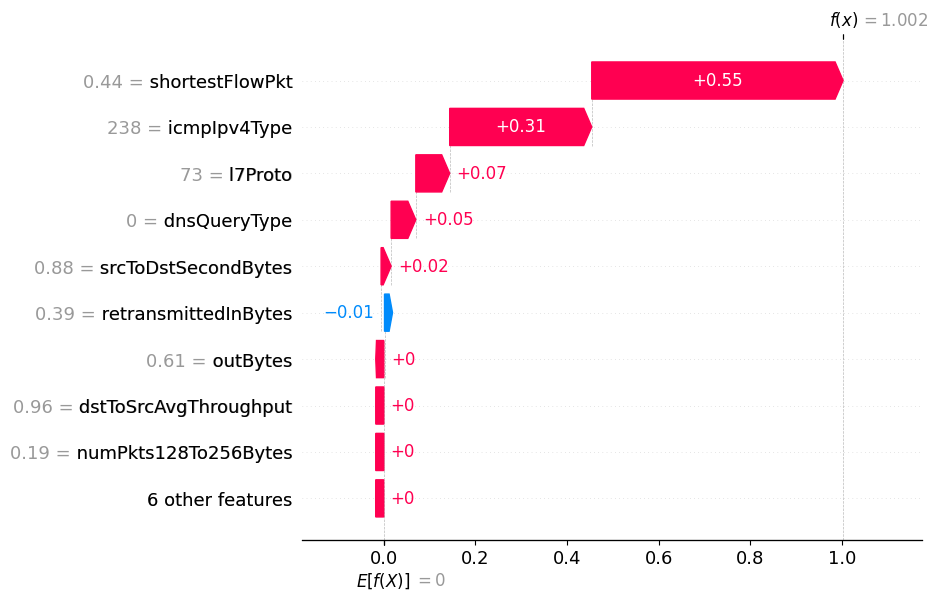

In [44]:
import shap
import numpy as np

# --- Wasserfall-Plot mit aggregierten Features ---

# 1. WÄHLEN SIE HIER DAS SAMPLE UND DIE KLASSE AUS, die Sie erklären möchten
SAMPLE_IDX = 99  # z.B. das 100. Sample
CLASS_IDX = 2    # z.B. die Klasse 'Output 2'

# 2. Extrahieren der Daten für dieses eine Sample
tokens = shap_values.data[SAMPLE_IDX].tolist()
# Wichtig: Für Wasserfall-Plots verwenden wir die rohen SHAP-Werte (nicht die absoluten),
# da wir sehen wollen, ob ein Feature den Wert nach oben (rot) oder unten (blau) drückt.
sv = shap_values.values[SAMPLE_IDX][:, CLASS_IDX]
# Der base_value (der durchschnittliche Startwert der Vorhersage) ist für alle Tokens gleich.
base_value = shap_values.base_values[SAMPLE_IDX][CLASS_IDX]

# 3. Die gleiche Segmentierungs- und Aggregationslogik wie zuvor
aggregated_features = []
separator_indices = [-1] + [k for k, t in enumerate(tokens) if t and '[SEP' in t]

for j in range(len(separator_indices) - 1):
    start_index = separator_indices[j] + 1
    end_index = separator_indices[j+1]
    if start_index >= end_index: continue

    segment_tokens = tokens[start_index:end_index]
    segment_sv = sv[start_index:end_index]

    feature_name = None
    feature_value_str = None
    try:
        colon_index = segment_tokens.index(': ')
        name_parts = segment_tokens[:colon_index]
        value_parts = segment_tokens[colon_index + 1:]

        # Name extrahieren und bereinigen
        cleaned_name_parts = [p.replace('[CLS]', '').strip() for p in name_parts if p.replace('[CLS]', '').strip()]
        if cleaned_name_parts: feature_name = "".join(cleaned_name_parts)

        # Wert extrahieren und bereinigen (für die Anzeige im Plot)
        if value_parts: feature_value_str = "".join(value_parts).strip()

    except (ValueError, IndexError):
        continue

    # Summiere die rohen SHAP-Werte für das Segment
    total_shap_for_feature = np.sum(segment_sv)

    if feature_name:
        aggregated_features.append({
            "name": feature_name,
            "value_str": feature_value_str,
            "shap_value": total_shap_for_feature
        })

# 4. Erstelle ein neues, benutzerdefiniertes SHAP Explanation-Objekt für den Plot
if aggregated_features:
    # Sortiere nach der Grösse des Beitrags, um die wichtigsten Features zu zeigen
    aggregated_features.sort(key=lambda x: abs(x["shap_value"]), reverse=True)
    TOP_N = 15 # Anzahl der Features, die im Plot gezeigt werden sollen

    top_features = aggregated_features[:TOP_N]
    
    # Bereite die Daten für das neue Objekt vor
    agg_shap_values = np.array([f["shap_value"] for f in top_features])
    agg_feature_names = [f["name"] for f in top_features]
    # Wir übergeben den extrahierten Wert des Features, damit er im Plot angezeigt wird
    agg_data = [f["value_str"] for f in top_features]

    # Erstelle das finale Explanation-Objekt
    agg_explanation = shap.Explanation(
        values=agg_shap_values,
        base_values=base_value,
        data=agg_data,
        feature_names=agg_feature_names
    )

    # 5. Erstelle den Wasserfall-Plot
    print(f"Wasserfall-Plot für Sample {SAMPLE_IDX} und Klasse {CLASS_IDX} (Top {TOP_N} Features)")
    shap.plots.waterfall(agg_explanation)
else:
    print("Konnte keine Features für den Wasserfall-Plot extrahieren.")

Top 20 wichtigste Features (Tokens) für Klasse 1:
token
44      0.187429
75      0.136184
97      0.118570
72      0.109725
122     0.098300
238     0.094120
95      0.092329
255     0.091483
03      0.090615
172     0.086925
174     0.082484
80      0.077897
14      0.073798
96      0.069787
88      0.069441
94      0.066707
87      0.064244
127     0.063694
203     0.058697
65      0.057530
76      0.053978
53      0.052542
226     0.052491
05      0.051307
83      0.048964
89      0.047833
30      0.047067
77      0.046614
208     0.046335
103     0.045568
93      0.042734
27      0.042128
36      0.037985
50      0.037913
79      0.037523
52      0.037283
85      0.036483
90      0.036141
63      0.035951
225     0.035332
84      0.034195
02      0.033432
109     0.031790
71      0.031628
38      0.031507
12      0.029901
114     0.029479
32      0.028548
21      0.026526
82      0.025800
Name: abs_shap_value, dtype: float64


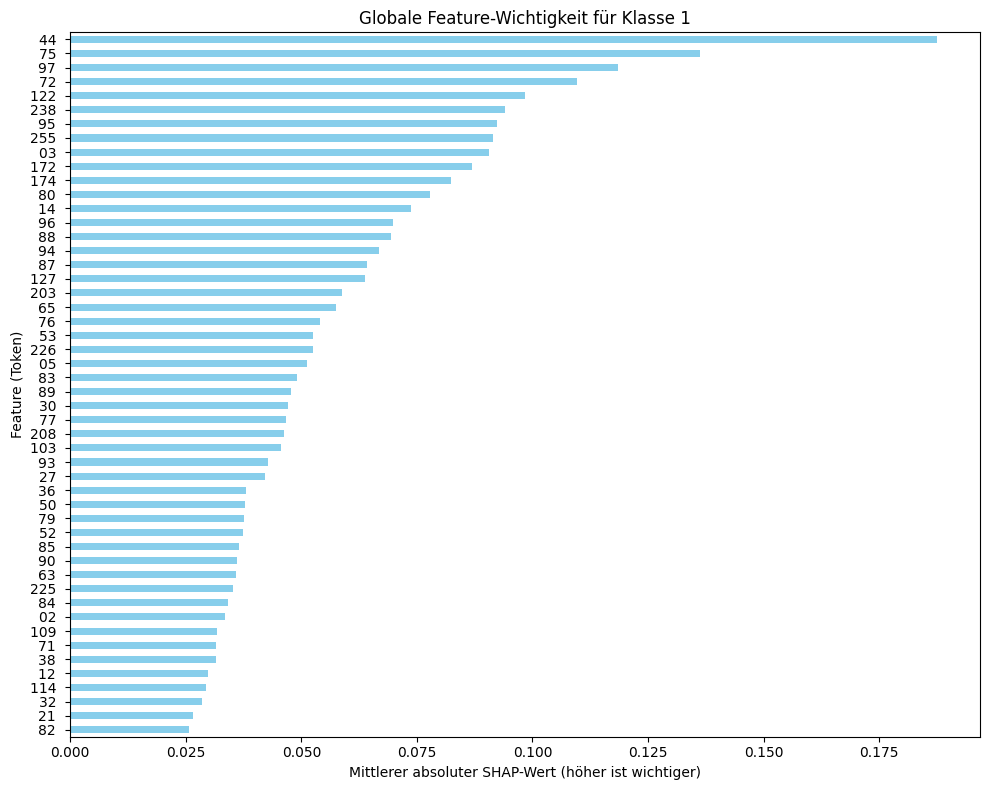

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Manuelle Berechnung und Visualisierung der globalen SHAP-Wichtigkeit ---

# Wählen Sie die Klasse, für die Sie die Wichtigkeit anzeigen möchten (z.B. Klasse 1)
CLASS_INDEX = 1

# Annahme: 'shap_values' ist das Ergebnis von explainer(val_texts[:5])
# und ist in der Umgebung verfügbar.

# 1. Erstellen Sie eine Liste von (Token, SHAP-Wert)-Tupeln für alle Samples
token_shap_pairs = []
for i in range(len(shap_values)):  # Iteriert über alle erklärten Samples
    # Extrahieren der Tokens und SHAP-Werte für das i-te Sample und die gewählte Klasse
    tokens = shap_values.data[i]
    sv = shap_values.values[i][:, CLASS_INDEX]

    # Filtern Sie spezielle Tokens und Padding-Tokens heraus
    for token, shap_val in zip(tokens, sv):
        if token and token not in ['[PAD]', '[CLS]', '[SEP]']:
            token_shap_pairs.append((token, abs(shap_val)))

# 2. Erstellen Sie ein Pandas DataFrame und berechnen Sie den Durchschnitt
df = pd.DataFrame(token_shap_pairs, columns=['token', 'abs_shap_value'])

# Gruppieren nach Token und den mittleren absoluten SHAP-Wert berechnen
mean_shap_df = df.groupby('token')['abs_shap_value'].mean().sort_values(ascending=False)

# 3. Die Top 20 Features plotten
print(f"Top 20 wichtigste Features (Tokens) für Klasse {CLASS_INDEX}:")
print(mean_shap_df.head(50))

plt.figure(figsize=(10, 8))
mean_shap_df.head(50).plot(kind='barh', color='skyblue')
plt.title(f'Globale Feature-Wichtigkeit für Klasse {CLASS_INDEX}')
plt.xlabel('Mittlerer absoluter SHAP-Wert (höher ist wichtiger)')
plt.ylabel('Feature (Token)')
plt.gca().invert_yaxis()  # Wichtigstes Feature oben anzeigen
plt.tight_layout()
plt.show()

Top 20 wichtigste Features für Klasse 2:
feature
shortestFlowPkt          0.393480
l7Proto                  0.214029
icmpIpv4Type             0.116991
srcToDstSecondBytes      0.084393
dstToSrcAvgThroughput    0.073394
dnsQueryType             0.052023
inPkts                   0.017247
retransmittedInBytes     0.010861
outBytes                 0.007984
longestFlowPkt           0.007366
inBytes                  0.005255
dstToSrcSecondBytes      0.002943
dstToSrcIatAvg           0.002350
numPkts128To256Bytes     0.001803
minIpPktLen              0.000767
Name: abs_shap_value, dtype: float64


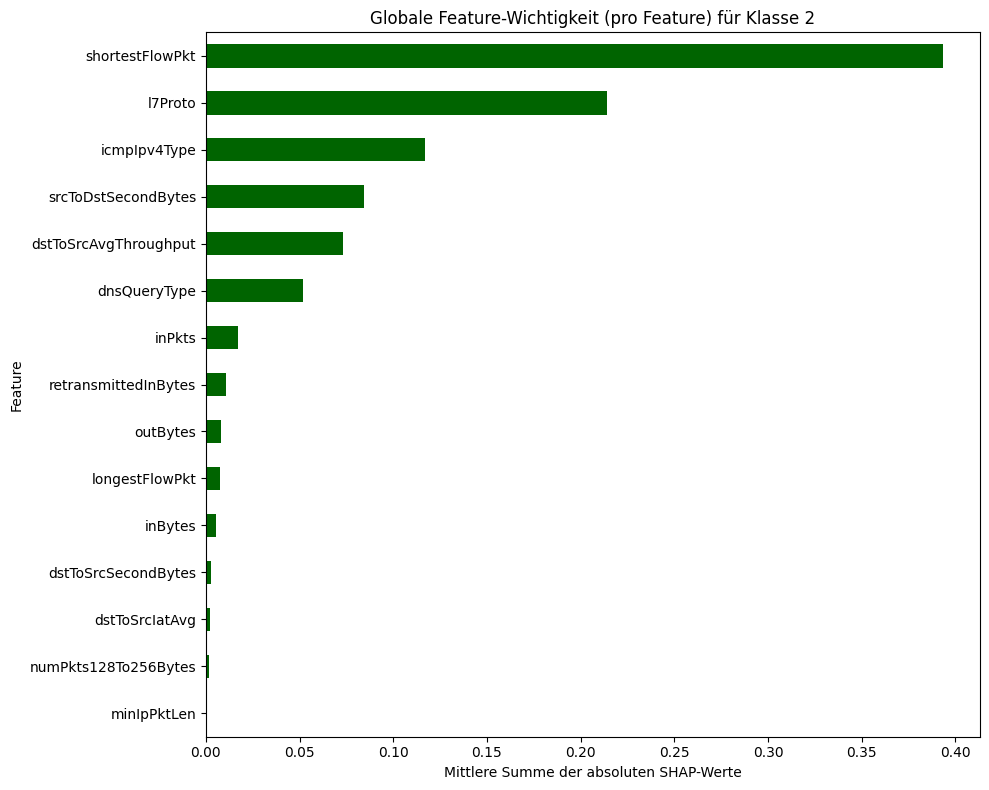

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Annahme: 'shap_values' ist das Ergebnis von explainer(...)
CLASS_INDEX = 2

feature_shap_values = []

# Iteriere durch jedes Sample
for i in range(shap_values.shape[0]):
    
    tokens = shap_values.data[i]
    if isinstance(tokens, np.ndarray):
        tokens = tokens.tolist()

    sv = shap_values.values[i][:, CLASS_INDEX]

    # Finde die Indizes der Trenn-Tokens. Wir suchen nach dem String '[SEP'.
    separator_indices = [-1] + [k for k, token in enumerate(tokens) if token and '[SEP' in token]

    # Iteriere durch die Segmente
    for j in range(len(separator_indices) - 1):
        start_index = separator_indices[j] + 1
        end_index = separator_indices[j+1]

        if start_index >= end_index:
            continue

        segment_tokens = tokens[start_index:end_index]
        segment_sv = sv[start_index:end_index]

        feature_name = None
        try:
            # KORREKTUR: Finde den Index des Doppelpunkt-Tokens mit Leerzeichen: ': '
            colon_index_in_segment = segment_tokens.index(': ')
            feature_name_parts = segment_tokens[:colon_index_in_segment]
            
            # Bereinige den Namen von '[CLS] ' und leeren Strings
            cleaned_parts = []
            for part in feature_name_parts:
                # Entferne '[CLS]' und überflüssige Leerzeichen
                cleaned_part = part.replace('[CLS]', '').strip()
                if cleaned_part:
                    cleaned_parts.append(cleaned_part)
            
            if cleaned_parts:
                feature_name = "".join(cleaned_parts)

        except (ValueError, IndexError):
            # Segment ohne ':' oder leeres Segment -> überspringen
            continue

        # Summiere die absoluten SHAP-Werte für dieses gesamte Feature-Segment
        total_abs_shap_for_feature = np.sum(np.abs(segment_sv))

        if feature_name:
            feature_shap_values.append((feature_name, total_abs_shap_for_feature))

# Erstelle ein DataFrame und berechne den Durchschnitt
if feature_shap_values:
    feature_df = pd.DataFrame(feature_shap_values, columns=['feature', 'abs_shap_value'])
    mean_feature_shap_df = feature_df.groupby('feature')['abs_shap_value'].mean().sort_values(ascending=False)

    # --- Visualisierung ---
    print(f"Top 20 wichtigste Features für Klasse {CLASS_INDEX}:")
    print(mean_feature_shap_df.head(20))

    plt.figure(figsize=(10, 8))
    mean_feature_shap_df.head(20).plot(kind='barh', color='darkgreen')
    plt.title(f'Globale Feature-Wichtigkeit (pro Feature) für Klasse {CLASS_INDEX}')
    plt.xlabel('Mittlere Summe der absoluten SHAP-Werte')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Fehler: Konnte auch mit der korrekten Token-Struktur keine Features extrahieren.")



In [39]:
# Bitte führen Sie nur diese eine, finale Diagnose-Zeile aus.
print(list(shap_values.data[0]))

['', '[CLS] ', 'ds', 'tTo', 'Sr', 'cA', 'v', 'gT', 'hr', 'ough', 'put', ': ', '0', '.', '83 ', '[SEP] ', 'ds', 'tTo', 'Sr', 'cIa', 'tA', 'v', 'g', ': ', '0', '.', '00 ', '[SEP] ', 'ds', 'tTo', 'Sr', 'cS', 'ec', 'ond', 'By', 'tes', ': ', '0', '.', '48 ', '[SEP] ', 'in', 'By', 'tes', ': ', '0', '.', '29 ', '[SEP] ', 'in', 'P', 'kt', 's', ': ', '0', '.', '07 ', '[SEP] ', 'longest', 'Flow', 'P', 'kt', ': ', '0', '.', '57 ', '[SEP] ', 'minI', 'pP', 'kt', 'Len', ': ', '0', '.', '66 ', '[SEP] ', 'nu', 'mP', 'kt', 's', '12', '8', 'To', '25', '6', 'By', 'tes', ': ', '0', '.', '00 ', '[SEP] ', 'out', 'By', 'tes', ': ', '0', '.', '31 ', '[SEP] ', 're', 'tra', 'ns', 'mit', 'ted', 'In', 'By', 'tes', ': ', '0', '.', '00 ', '[SEP] ', 'shortest', 'Flow', 'P', 'kt', ': ', '0', '.', '52 ', '[SEP] ', 'sr', 'cT', 'oDs', 'tS', 'ec', 'ond', 'By', 'tes', ': ', '0', '.', '61 ', '[SEP] ', 'l', '7', 'Pro', 'to', ': ', '103 ', '[SEP] ', 'd', 'ns', 'Que', 'ry', 'Type', ': ', '1 ', '[SEP] ', 'ic', 'mp', 'Ip', 'v',